# Programiranje 3: Januar 2024



### Uputstva

* Ispit traje 120 min
* Ovu svesku je potrebno preimenovati tako da naziv bude u formatu: Prezime_Ime_Indeks (izbegavati naša slova u imenu i prezimenu, kao i '/' u broju indeksa - koristiti '_' umesto '/')
* Dozvoljeno je korišćenje samo onih materijala koji se nalaze u folderu P3 Jan 2024 na desktopu
* Nije dozvoljeno korišćenje Interneta
* Strogo je zabranjeno fotografisanje ili umnožavanje zadatka na bilo koji način; povreda ovog pravila se strogo kažnjava
* Zadaci sa kompajlerskim greškama se ne pregledaju i automatski se ocenjuju sa 0 poena
* Nakon završenog ispita treba ostaviti otvoreno razvojno okruženje (dakle, ne zatvarati ga)

### O ispitnom zadatku

* Zahtevi ispitnog zadatka odnose se na skup podataka o filmovima, preuzetim sa IMDB sajta.
* Za svaki zahtev ili grupu zahteva zadatka je naveden broj poena koji nosi.
* Prva grupa zahteva se odnosi na pripremu podataka za analizu i u tom smislu predstavlja preduslov za kasnije zahteve zadatka. 
* Ispod svakog zahteva zadatka ostavljena je jedna ćelija za kod, na Vama je da dodatne potrebne dodatne ćelije (što za kod, što za tekst), u meri koliko Vam je potrebno za dati zahtev zadatka.

### 1. Učitavanje i priprema podataka (ukupno 15p)

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from collections import defaultdict

#### 1.1 Učitatiti podatke iz fajla *imdb_top_1000_tr.csv* i kreirati DataFrame koji će biti korišćen u daljem radu

In [47]:
data = pd.read_csv(Path.cwd() / "data" / "imdb_top_1000_tr.csv")

In [48]:
data.head(10)

,Title,Released_Year,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Stars,Director,No_of_Votes,Gross
0,The Shawshank Redemption,1994,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,"['Tim Robbins', 'Morgan Freeman', 'Bob Gunton'...",Frank Darabont,2343110,"28,341,469"
1,The Godfather,1972,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,"['Marlon Brando', 'Al Pacino', 'James Caan', '...",Francis Ford Coppola,1620367,"134,966,411"
2,The Dark Knight,2008,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,"['Christian Bale', 'Heath Ledger', 'Aaron Eckh...",Christopher Nolan,2303232,"534,858,444"
3,The Godfather: Part II,1974,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,"['Al Pacino', 'Robert De Niro', 'Robert Duvall...",Francis Ford Coppola,1129952,"57,300,000"
4,12 Angry Men,1957,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,"['Henry Fonda', 'Lee J. Cobb', 'Martin Balsam'...",Sidney Lumet,689845,"4,360,000"
5,The Lord of the Rings: The Return of the King,2003,201 min,"Action, Adventure, Drama",8.9,Gandalf and Aragorn lead the World of Men agai...,94.0,"['Elijah Wood', 'Viggo Mortensen', 'Ian McKell...",Peter Jackson,1642758,"377,845,905"
6,Pulp Fiction,1994,154 min,"Crime, Drama",8.9,"The lives of two mob hitmen, a boxer, a gangst...",94.0,"['John Travolta', 'Uma Thurman', 'Samuel L. Ja...",Quentin Tarantino,1826188,"107,928,762"
7,Schindler's List,1993,195 min,"Biography, Drama, History",8.9,"In German-occupied Poland during World War II,...",94.0,"['Liam Neeson', 'Ralph Fiennes', 'Ben Kingsley...",Steven Spielberg,1213505,"96,898,818"
8,Inception,2010,148 min,"Action, Adventure, Sci-Fi",8.8,A thief who steals corporate secrets through t...,74.0,"['Leonardo DiCaprio', 'Joseph Gordon-Levitt', ...",Christopher Nolan,2067042,"292,576,195"
9,Fight Club,1999,139 min,Drama,8.8,An insomniac office worker and a devil-may-car...,66.0,"['Brad Pitt', 'Edward Norton', 'Meat Loaf', 'Z...",David Fincher,1854740,"37,030,102"


#### 1.2 Odrediti broj redova i kolona u kreiranom DataFrame-u, kao i tipove podataka atributa (kolona)

In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Title          1000 non-null   object 
 1   Released_Year  1000 non-null   object 
 2   Runtime        1000 non-null   object 
 3   Genre          1000 non-null   object 
 4   IMDB_Rating    1000 non-null   float64
 5   Overview       1000 non-null   object 
 6   Meta_score     843 non-null    float64
 7   Stars          1000 non-null   object 
 8   Director       1000 non-null   object 
 9   No_of_Votes    1000 non-null   int64  
 10  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(8)
memory usage: 86.1+ KB


#### 1.3 Proveriti prisustvo nedostajućih vrednosti i obrisati sve redove koji imaju makar jednu nedostajuću vrednost

In [50]:
data.isna().sum()

Title              0
Released_Year      0
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Stars              0
Director           0
No_of_Votes        0
Gross            169
dtype: int64

In [51]:
data.dropna(inplace=True, how='any')
data.shape

(750, 11)

#### 1.4 Transformisati kolone u numeričke

* Kreirati kolonu `Runtime_mins` koja predstavlja broj minuta trajanja filma, izrazen kao int podatak, a zatim obrisati `Runtime` kolonu
* Kolone `Released_Year` i `Gross` transformisati u numeričke. 
* Ukoliko neka od navedenih kolona ima vrednosti koje se ne mogu transformisati u numeričke, obrisati redove sa takvim vrednostima (bilo pre ili nakon transformacije)    

In [52]:
def runtime_to_num(runtime_str):
    min_str, _ = runtime_str.split()
    return int(min_str)

data['Runtime_mins'] = data.Runtime.apply(runtime_to_num)

In [53]:
data.drop(columns='Runtime', inplace=True)

In [54]:
def gross_to_int(gross_str):
    return int(gross_str.replace(",", ""))

data.Gross = data.Gross.apply(gross_to_int)

In [55]:
data.Released_Year = pd.to_numeric(data.Released_Year, errors='coerce')

In [56]:
data[['Released_Year', 'Gross', 'Runtime_mins']].isna().sum()

Released_Year    1
Gross            0
Runtime_mins     0
dtype: int64

In [57]:
data.dropna(how='any', inplace=True, subset='Released_Year')

In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 749 entries, 0 to 997
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Title          749 non-null    object 
 1   Released_Year  749 non-null    float64
 2   Genre          749 non-null    object 
 3   IMDB_Rating    749 non-null    float64
 4   Overview       749 non-null    object 
 5   Meta_score     749 non-null    float64
 6   Stars          749 non-null    object 
 7   Director       749 non-null    object 
 8   No_of_Votes    749 non-null    int64  
 9   Gross          749 non-null    int64  
 10  Runtime_mins   749 non-null    int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 70.2+ KB


In [59]:
data.Released_Year = data.Released_Year.astype(int)

In [60]:
data[['Gross', 'Runtime_mins', 'Released_Year']].head(10)

,Gross,Runtime_mins,Released_Year
0,28341469,142,1994
1,134966411,175,1972
2,534858444,152,2008
3,57300000,202,1974
4,4360000,96,1957
5,377845905,201,2003
6,107928762,154,1994
7,96898818,195,1993
8,292576195,148,2010
9,37030102,139,1999


In [61]:
data.reset_index(drop=True, inplace=True)
data.index

RangeIndex(start=0, stop=749, step=1)

#### 2. Za svaku godinu od 2000 god. pa nadalje, odrediti broj filmova na IMDB Top listi, kao i prosečnu zaradu (Gross) koju su filmovi ostvarili u toj godini. Grafički prikazati prosečnu zaradu u svakoj godini (15p)

In [62]:
from_2000 = data.loc[data.Released_Year >= 2000,]
yearly_stats = from_2000.groupby('Released_Year')['Gross'].agg(['count', 'mean'])

In [63]:
yearly_stats.columns = ['N_movies', 'Mean_Revenue']
yearly_stats

,N_movies,Mean_Revenue
Released_Year,,
2000,16,5.333543e+07
2001,24,8.739662e+07
2002,18,6.243993e+07
2003,21,7.080961e+07
2004,28,5.162240e+07
2005,14,7.307402e+07
2006,22,5.431234e+07
2007,23,4.251145e+07
2008,17,1.075356e+08


In [64]:
x = yearly_stats.index.tolist()
y = yearly_stats.Mean_Revenue.tolist()

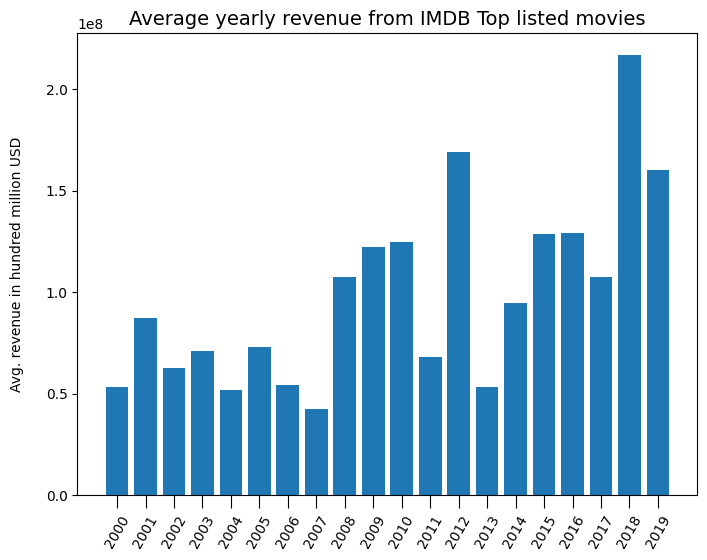

In [65]:
_, ax = plt.subplots(figsize=(8,6))
ax.bar(x, y)
ax.set_xlabel("")
ax.set_xticks(range(2000, max(x)+1))
ax.tick_params(axis ='x', rotation = 60, size=9)
ax.set_ylabel("Avg. revenue in hundred million USD\n")
ax.set_title("Average yearly revenue from IMDB Top listed movies", fontsize=14)
plt.show()

#### 3. Za svaki žanr, odrediti broj filmova koji pripadaju tom žanru i prosečan IMDB rejting za žanr.  Prikazati broj filmova po žanru u formi horizontalnog bar chart-a (nazivi žanrova na y osi, broj filmova na x osi); prikaz treba da bude sortiran po broju filmova (20p)

Napomena: Neki filmovi su svrstani u više žanrova; takve filmove računati za svaki žanr kome pripadaju - npr. ako je za žanr filma navedeno "Action, Drama", računati da pripada i Action i Drama žanru. 

In [66]:
data.Genre.sample(5)

139                        Drama
453                 Crime, Drama
268    Mystery, Sci-Fi, Thriller
140        Action, Drama, Sci-Fi
570         Action, Crime, Drama
Name: Genre, dtype: object

In [67]:
genres = set()

for genre_str in data.Genre.values:
    if ',' in genre_str:
        genres.update([g.strip() for g in genre_str.split(',')])
    else:
        genres.add(genre_str)
        
genres

{'Action',
 'Adventure',
 'Animation',
 'Biography',
 'Comedy',
 'Crime',
 'Drama',
 'Family',
 'Fantasy',
 'Film-Noir',
 'History',
 'Horror',
 'Music',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Sport',
 'Thriller',
 'War',
 'Western'}

In [68]:
genre_rating = defaultdict(list)
n_rows = data.shape[0]

for genre in genres:
    for i in range(n_rows):
        if genre in data.Genre.iloc[i]:
            genre_rating[genre].append(data.IMDB_Rating.iloc[i])
                    

In [69]:
from statistics import mean

for genre, ratings in genre_rating.items():
    n_movies = len(ratings)
    avg_rating = mean(ratings)
    print(f"{genre.upper()}: {n_movies} movies, avg IMDB rating: {mean(ratings):.3f}")

FILM-NOIR: 8 movies, avg IMDB rating: 8.037
DRAMA: 530 movies, avg IMDB rating: 7.940
COMEDY: 166 movies, avg IMDB rating: 7.873
ANIMATION: 64 movies, avg IMDB rating: 7.922
ADVENTURE: 164 movies, avg IMDB rating: 7.962
SPORT: 17 movies, avg IMDB rating: 7.918
THRILLER: 104 movies, avg IMDB rating: 7.914
HORROR: 21 movies, avg IMDB rating: 7.886
FAMILY: 45 movies, avg IMDB rating: 7.871
ROMANCE: 91 movies, avg IMDB rating: 7.922
FANTASY: 55 movies, avg IMDB rating: 7.902
MYSTERY: 73 movies, avg IMDB rating: 7.952
BIOGRAPHY: 88 movies, avg IMDB rating: 7.909
WAR: 33 movies, avg IMDB rating: 7.997
MUSICAL: 11 movies, avg IMDB rating: 7.918
SCI-FI: 58 movies, avg IMDB rating: 7.993
HISTORY: 38 movies, avg IMDB rating: 7.921
WESTERN: 16 movies, avg IMDB rating: 8.037
CRIME: 151 movies, avg IMDB rating: 7.942
ACTION: 143 movies, avg IMDB rating: 7.935
MUSIC: 36 movies, avg IMDB rating: 7.908


In [70]:
genre_counts = [(g, len(ratings)) for g, ratings in genre_rating.items()]
genre_counts.sort(key=lambda item: item[1])

x = [g for g, _ in genre_counts]
y = [g_count for _, g_count in genre_counts]

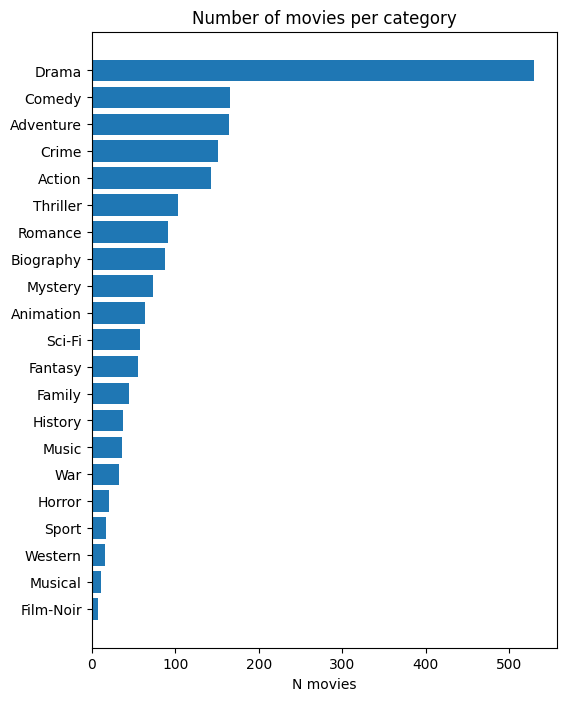

In [71]:
_, ax = plt.subplots(figsize=(6,8))
ax.barh(x, y)
ax.set_title("Number of movies per category")
ax.set_xlabel("N movies")

plt.show()

#### 4. Utvrditi koji glumci / glumice su igrali u najviše filmova na ovoj IMDB top listi i kreirati listu rečnika koji sadrže podatke o tim glumcima / glumicama. Preciznije, za 10 najzastupljenijih glumaca / glumica, trebalo bi kreirati listu rečnika sledećeg oblika: 
```
{
    "name": <actor/actress_name>,
    "n_movies": <number_of_movies>,
    "avg_imdb_rating": <mean_IMDB_rating_of_the_movies>,
    "years_active": (<year_of_the_first_movie>, <year_of_the_last_movie>)
}
```
 
#### Ovako kreiranu listu je potrebno upisati u json fajl 'top_IMDB_movie_stars.json' (20p)

Hint: primetite da kolona Stars ne sadrži listu imena glumaca, već listu zapisanu kao string. Funkcija `literal_eval()` iz `ast` paketa omogućuje da se takav string pretvori u pravu python listu.



In [72]:
data.Stars.sample()

278    ['Danny Aiello', 'Ossie Davis', 'Ruby Dee', 'R...
Name: Stars, dtype: object

In [73]:
data.Stars[0]

"['Tim Robbins', 'Morgan Freeman', 'Bob Gunton', 'William Sadler']"

In [74]:
from ast import literal_eval

data.Stars = data.Stars.apply(literal_eval)

In [75]:
data.Stars[0]

['Tim Robbins', 'Morgan Freeman', 'Bob Gunton', 'William Sadler']

In [76]:
all_stars = list()

for movie_stars in data.Stars:
    all_stars.extend(movie_stars)
    
print(len(all_stars))
print(len(set(all_stars)))

2996
2030


In [77]:
from collections import Counter

star_counts = Counter(all_stars)

star_series = pd.Series(data=star_counts.values(), index=star_counts.keys())
top_10_stars = star_series.sort_values(ascending=False).head(10)

top_10_stars

Robert De Niro        16
Tom Hanks             13
Al Pacino             13
Brad Pitt             12
Clint Eastwood        11
Christian Bale        11
Matt Damon            11
Leonardo DiCaprio     11
Scarlett Johansson     9
Ethan Hawke            9
dtype: int64

In [78]:
def collect_star_data(stars):
    from statistics import mean
    
    stars_dict_list = list()
    
    for star in stars:
        imdb_ratings = list()
        released_years = list()
        for i in range(data.shape[0]):
            if star in data.Stars.iloc[i]:
                imdb_ratings.append(data.IMDB_Rating.iloc[i])
                released_years.append(int(data.Released_Year.iloc[i]))
        star_dict = {
            'name': star,
            'n_movies': len(imdb_ratings),
            'avg_imdb_rating': mean(imdb_ratings),
            'years_active': (min(released_years), max(released_years))
        }
        stars_dict_list.append(star_dict)
        
    return stars_dict_list

In [79]:
stars_list = collect_star_data(top_10_stars.index.to_list())

In [80]:
# from pprint import pprint
#
# for s in stars_list:
#     pprint(s)

In [81]:
import json

with open(Path.cwd() / 'top_IMDB_movie_stars.json', 'w') as fobj:
    json.dump(stars_list, fobj, indent=4)
    